# 🎓 Student Management System Analysis

A complete structured data analysis project using Python.

## 📌 1. Import Libraries

In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (8,5)

os.makedirs("outputs/graphs", exist_ok=True)

## 📂 2. Load Dataset

In [11]:
# Load dataset
df = pd.read_csv('student_data.csv')
df.head(10)

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4
5,1006,18,0,0,1,8.191219,0,0,1,1,0,0,0,3.084184,1
6,1007,15,0,1,1,15.601680,10,0,3,0,1,0,0,2.748237,2
7,1008,15,1,1,4,15.424496,22,1,1,1,0,0,0,1.360143,4
8,1009,17,0,0,0,4.562008,1,0,2,0,1,0,1,2.896819,2
9,1010,16,1,0,1,18.444466,0,0,3,1,0,0,0,3.573474,0


## 🔍 3. Data Overview

In [ ]:
df.info()
print(df.shape)
df.describe()
print(df.isnull().sum())
df.columns




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 18 columns):
 #   Column             Non-Null Count  Dtype   
---  ------             --------------  -----   
 0   StudentID          2392 non-null   int64   
 1   Age                2392 non-null   int64   
 2   Gender             2392 non-null   int64   
 3   Ethnicity          2392 non-null   int64   
 4   ParentalEducation  2392 non-null   int64   
 5   StudyTimeWeekly    2392 non-null   float64 
 6   Absences           2392 non-null   int64   
 7   Tutoring           2392 non-null   int64   
 8   ParentalSupport    2392 non-null   int64   
 9   Extracurricular    2392 non-null   int64   
 10  Sports             2392 non-null   int64   
 11  Music              2392 non-null   int64   
 12  Volunteering       2392 non-null   int64   
 13  GPA                2392 non-null   float64 
 14  GradeClass         2392 non-null   int64   
 15  PerformanceBand    2392 non-null   category
 16  HighAb

array([19.83372281, 15.40875606,  4.21056977, ...,  6.80549965,
       12.41665266, 17.81990749], shape=(2392,))

## 🔍 4. Unique Values

In [25]:
print(df["Gender"].unique()	)
print(df["StudentID"].unique())
print(df["Age"].unique())
print(df["Gender"].unique())
print(df["Ethnicity"].unique())
print(df["ParentalEducation"].unique())
print(df["StudyTimeWeekly"].unique())
print(df["Absences"].unique())
print(df["Tutoring"].unique())
print(df["ParentalSupport"].unique())
print(df["Extracurricular"].unique())
print(df["Sports"].unique())
print(df["Music"].unique())
print(df["Volunteering"].unique())
print(df["GPA"].unique())
print(df["GradeClass"].unique())

[1 0]
[1001 1002 1003 ... 3390 3391 3392]
[17 18 15 16]
[1 0]
[0 2 1 3]
[2 1 3 4 0]
[19.83372281 15.40875606  4.21056977 ...  6.80549965 12.41665266
 17.81990749]
[ 7  0 26 14 17 10 22  1 11 15 21  9 16 29  2 25 20  5  8 12 27 23  3 13
  6 28  4 18 19 24]
[1 0]
[2 1 3 4 0]
[0 1]
[0 1]
[1 0]
[0 1]
[2.92919559 3.04291483 0.11260225 ... 1.14233288 1.80329676 2.14001388]
[2 1 4 3 0]


## 🔍 5. Rename Columns

In [26]:
df = df.rename(columns={
    'StudyTimeWeekly': 'study_hours',
    'GPA': 'gpa'
})


df['attendance'] = 100 - df['Absences']

# Remove missing values
df = df.dropna()

df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,study_hours,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,gpa,GradeClass,PerformanceBand,HighAbsence,HighStudy,attendance
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2,Good,0,1,93
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1,Excellent,0,1,100
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4,Low,1,0,74
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3,Good,0,1,86
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4,Below Avg,1,0,83


## 🧹 4. Data Cleaning

In [27]:

df = df.dropna()
df = df.drop_duplicates()

### Analysis By GroupBy

In [51]:
print(df.groupby('Gender')['gpa'].mean())
print(df.groupby('ParentalEducation')['gpa'].mean())
print(df.groupby('Extracurricular')['gpa'].mean())

Gender
0    1.918679
1    1.894225
Name: gpa, dtype: float64
ParentalEducation
0    1.893045
1    1.944022
2    1.929881
3    1.809082
4    1.815812
Name: gpa, dtype: float64
Extracurricular
0    1.838316
1    2.015357
Name: gpa, dtype: float64


## 📊 5. Exploratory Data Analysis (EDA)

In [28]:
df

,StudentID,Age,Gender,Ethnicity,ParentalEducation,study_hours,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,gpa,GradeClass,PerformanceBand,HighAbsence,HighStudy,attendance
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2,Good,0,1,93
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1,Excellent,0,1,100
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4,Low,1,0,74
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3,Good,0,1,86
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4,Below Avg,1,0,83
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2387,3388,18,1,0,3,10.680555,2,0,4,1,0,0,0,3.455509,0,Excellent,0,1,98
2388,3389,17,0,0,1,7.583217,4,1,4,0,1,0,0,3.279150,4,Excellent,0,0,96
2389,3390,16,1,0,2,6.805500,20,0,2,0,0,0,1,1.142333,2,Below Avg,1,0,80
2390,3391,16,1,1,0,12.416653,17,0,2,0,1,1,0,1.803297,1,Below Avg,1,1,83


<Axes: xlabel='gpa', ylabel='Count'>

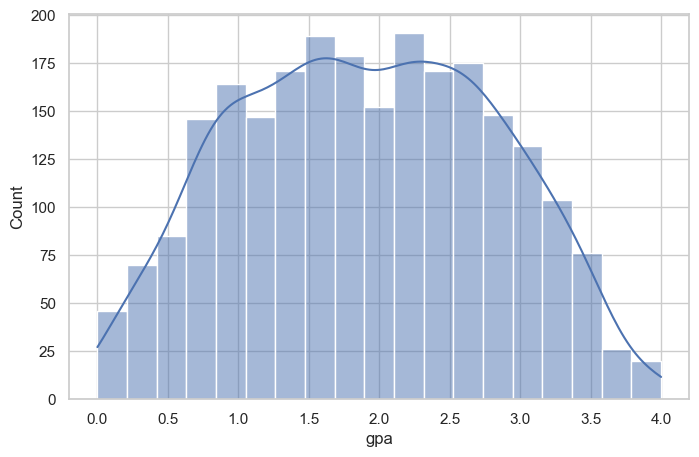

In [36]:
sns.histplot(df['gpa'], kde=True)

###  Gender Distribution

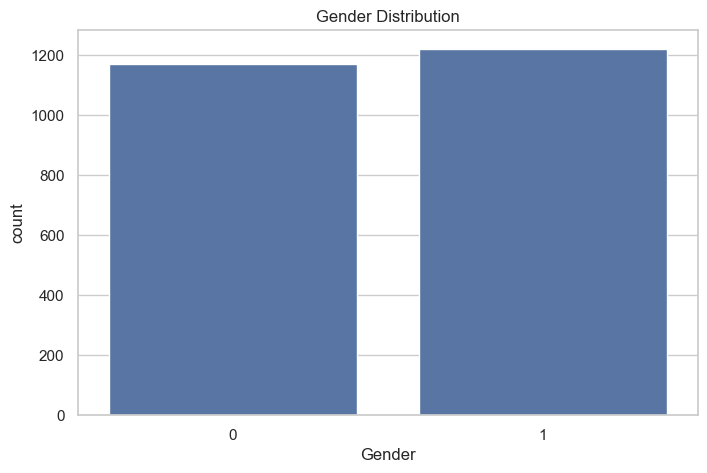

In [37]:
plt.figure()
sns.countplot(x='Gender', data=df)
plt.title('Gender Distribution')
plt.show()

###  Study Time Distribution

<Axes: xlabel='study_hours', ylabel='Count'>

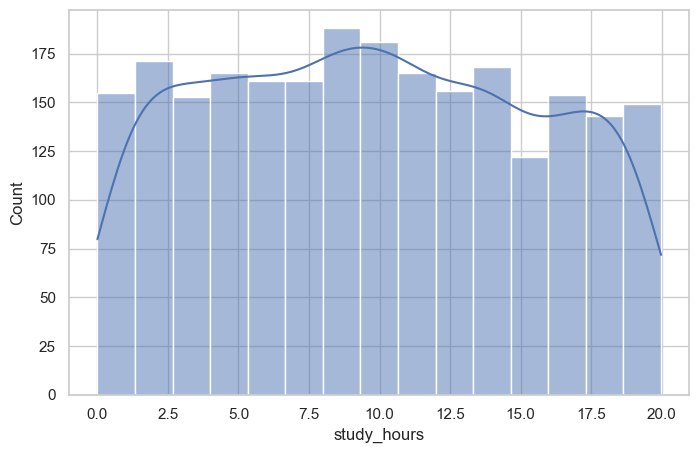

In [39]:
sns.histplot(df['study_hours'], kde=True)

###  Absences Distribution

<Axes: xlabel='Absences', ylabel='Count'>

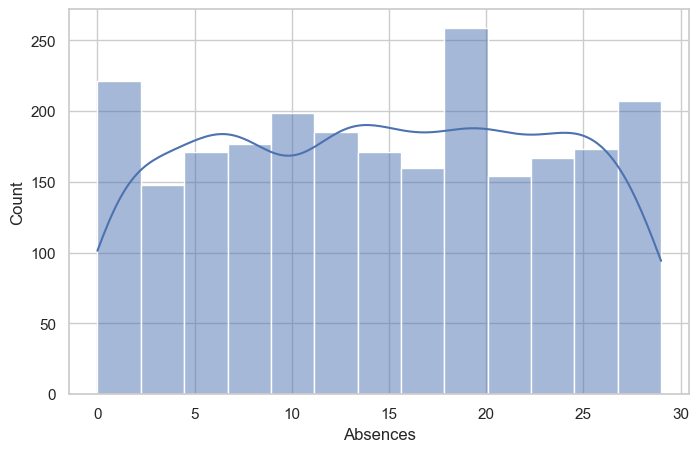

In [41]:
sns.histplot(df['Absences'], kde=True)

###  Parental Support vs GPA

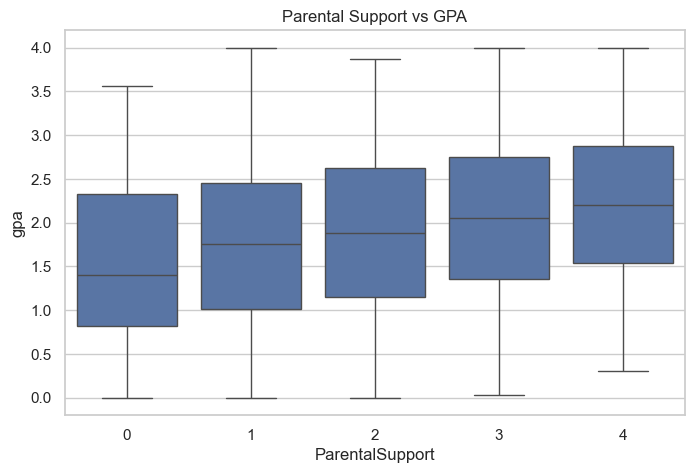

In [43]:
plt.figure()
sns.boxplot(x='ParentalSupport', y='gpa', data=df)
plt.title("Parental Support vs GPA")
plt.show()

### GPA KDE

<Axes: xlabel='gpa', ylabel='Density'>

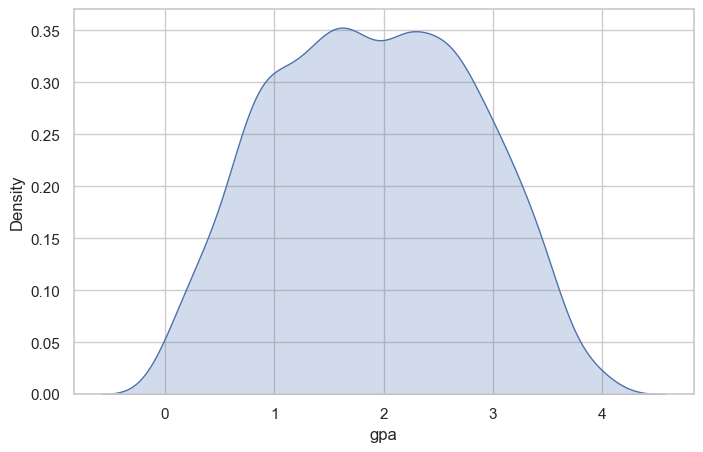

In [44]:
sns.kdeplot(df['gpa'], fill=True)

###  GPA Box

<Axes: xlabel='gpa'>

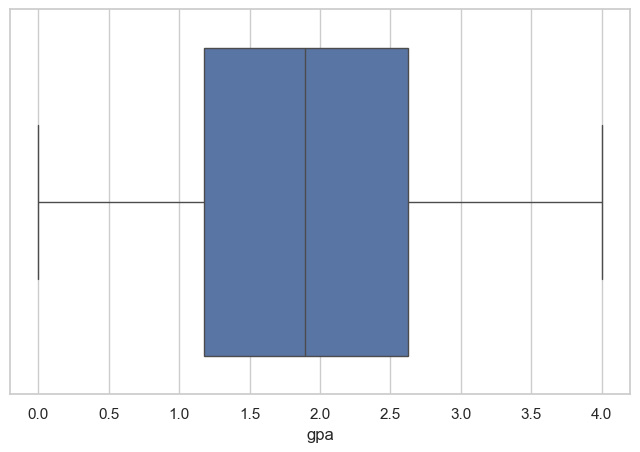

In [45]:
sns.boxplot(x=df['gpa'])

### Age Distribution

<Axes: xlabel='Age', ylabel='Count'>

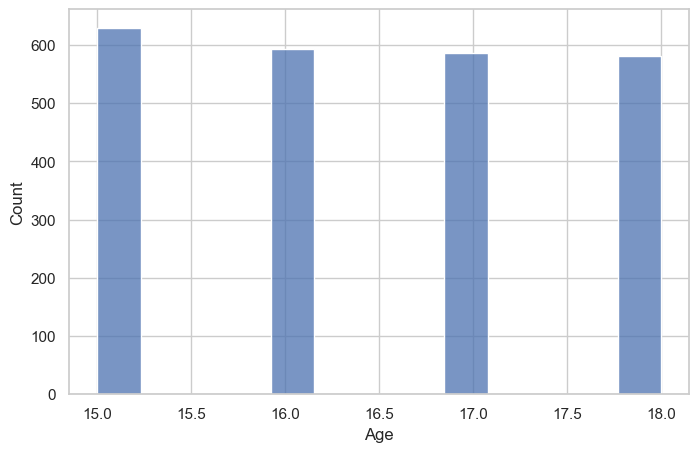

In [46]:
sns.histplot(df['Age'])

### Gender vs GPA

<Axes: xlabel='Gender', ylabel='gpa'>

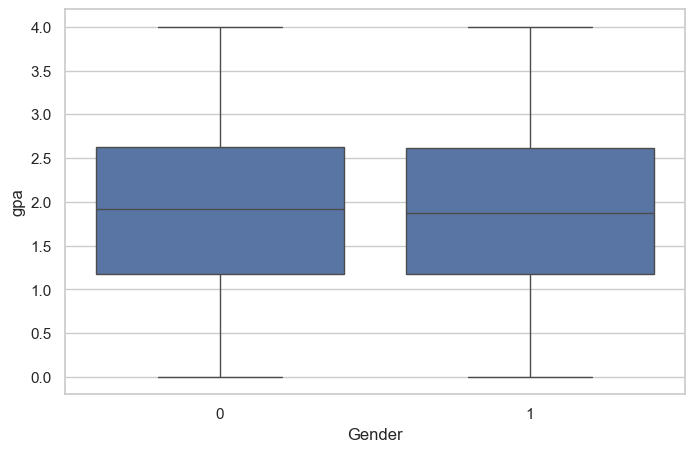

In [47]:
sns.boxplot(x='Gender', y='gpa', data=df)

### Pivot Heatmap

<Axes: xlabel='GradeClass', ylabel='Gender'>

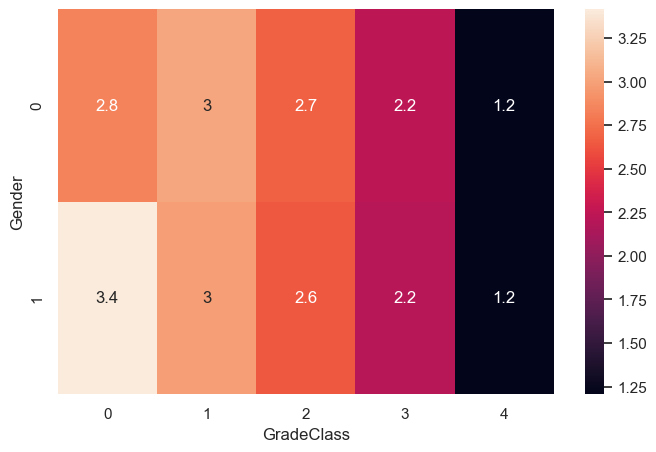

In [48]:
pivot = df.pivot_table(values='gpa', index='Gender', columns='GradeClass')
sns.heatmap(pivot, annot=True)

### Sort Values

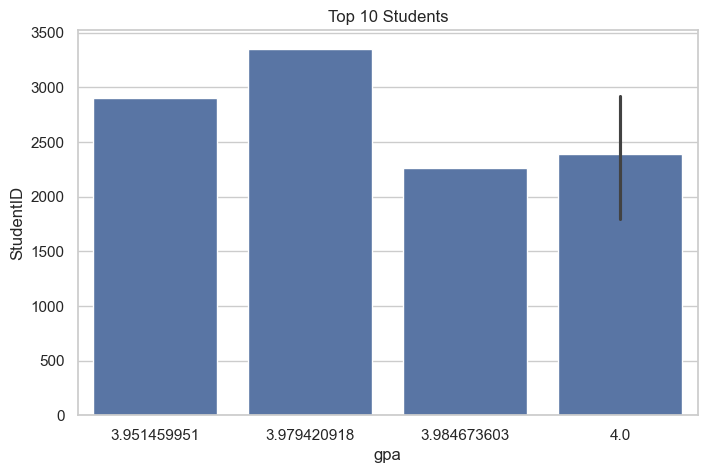

In [52]:
top10 = df.sort_values(by='gpa', ascending=False).head(10)

sns.barplot(x='gpa', y='StudentID', data=top10)
plt.title("Top 10 Students")
plt.show()

## 📈 6. Advanced Visualizations

### Pairplot

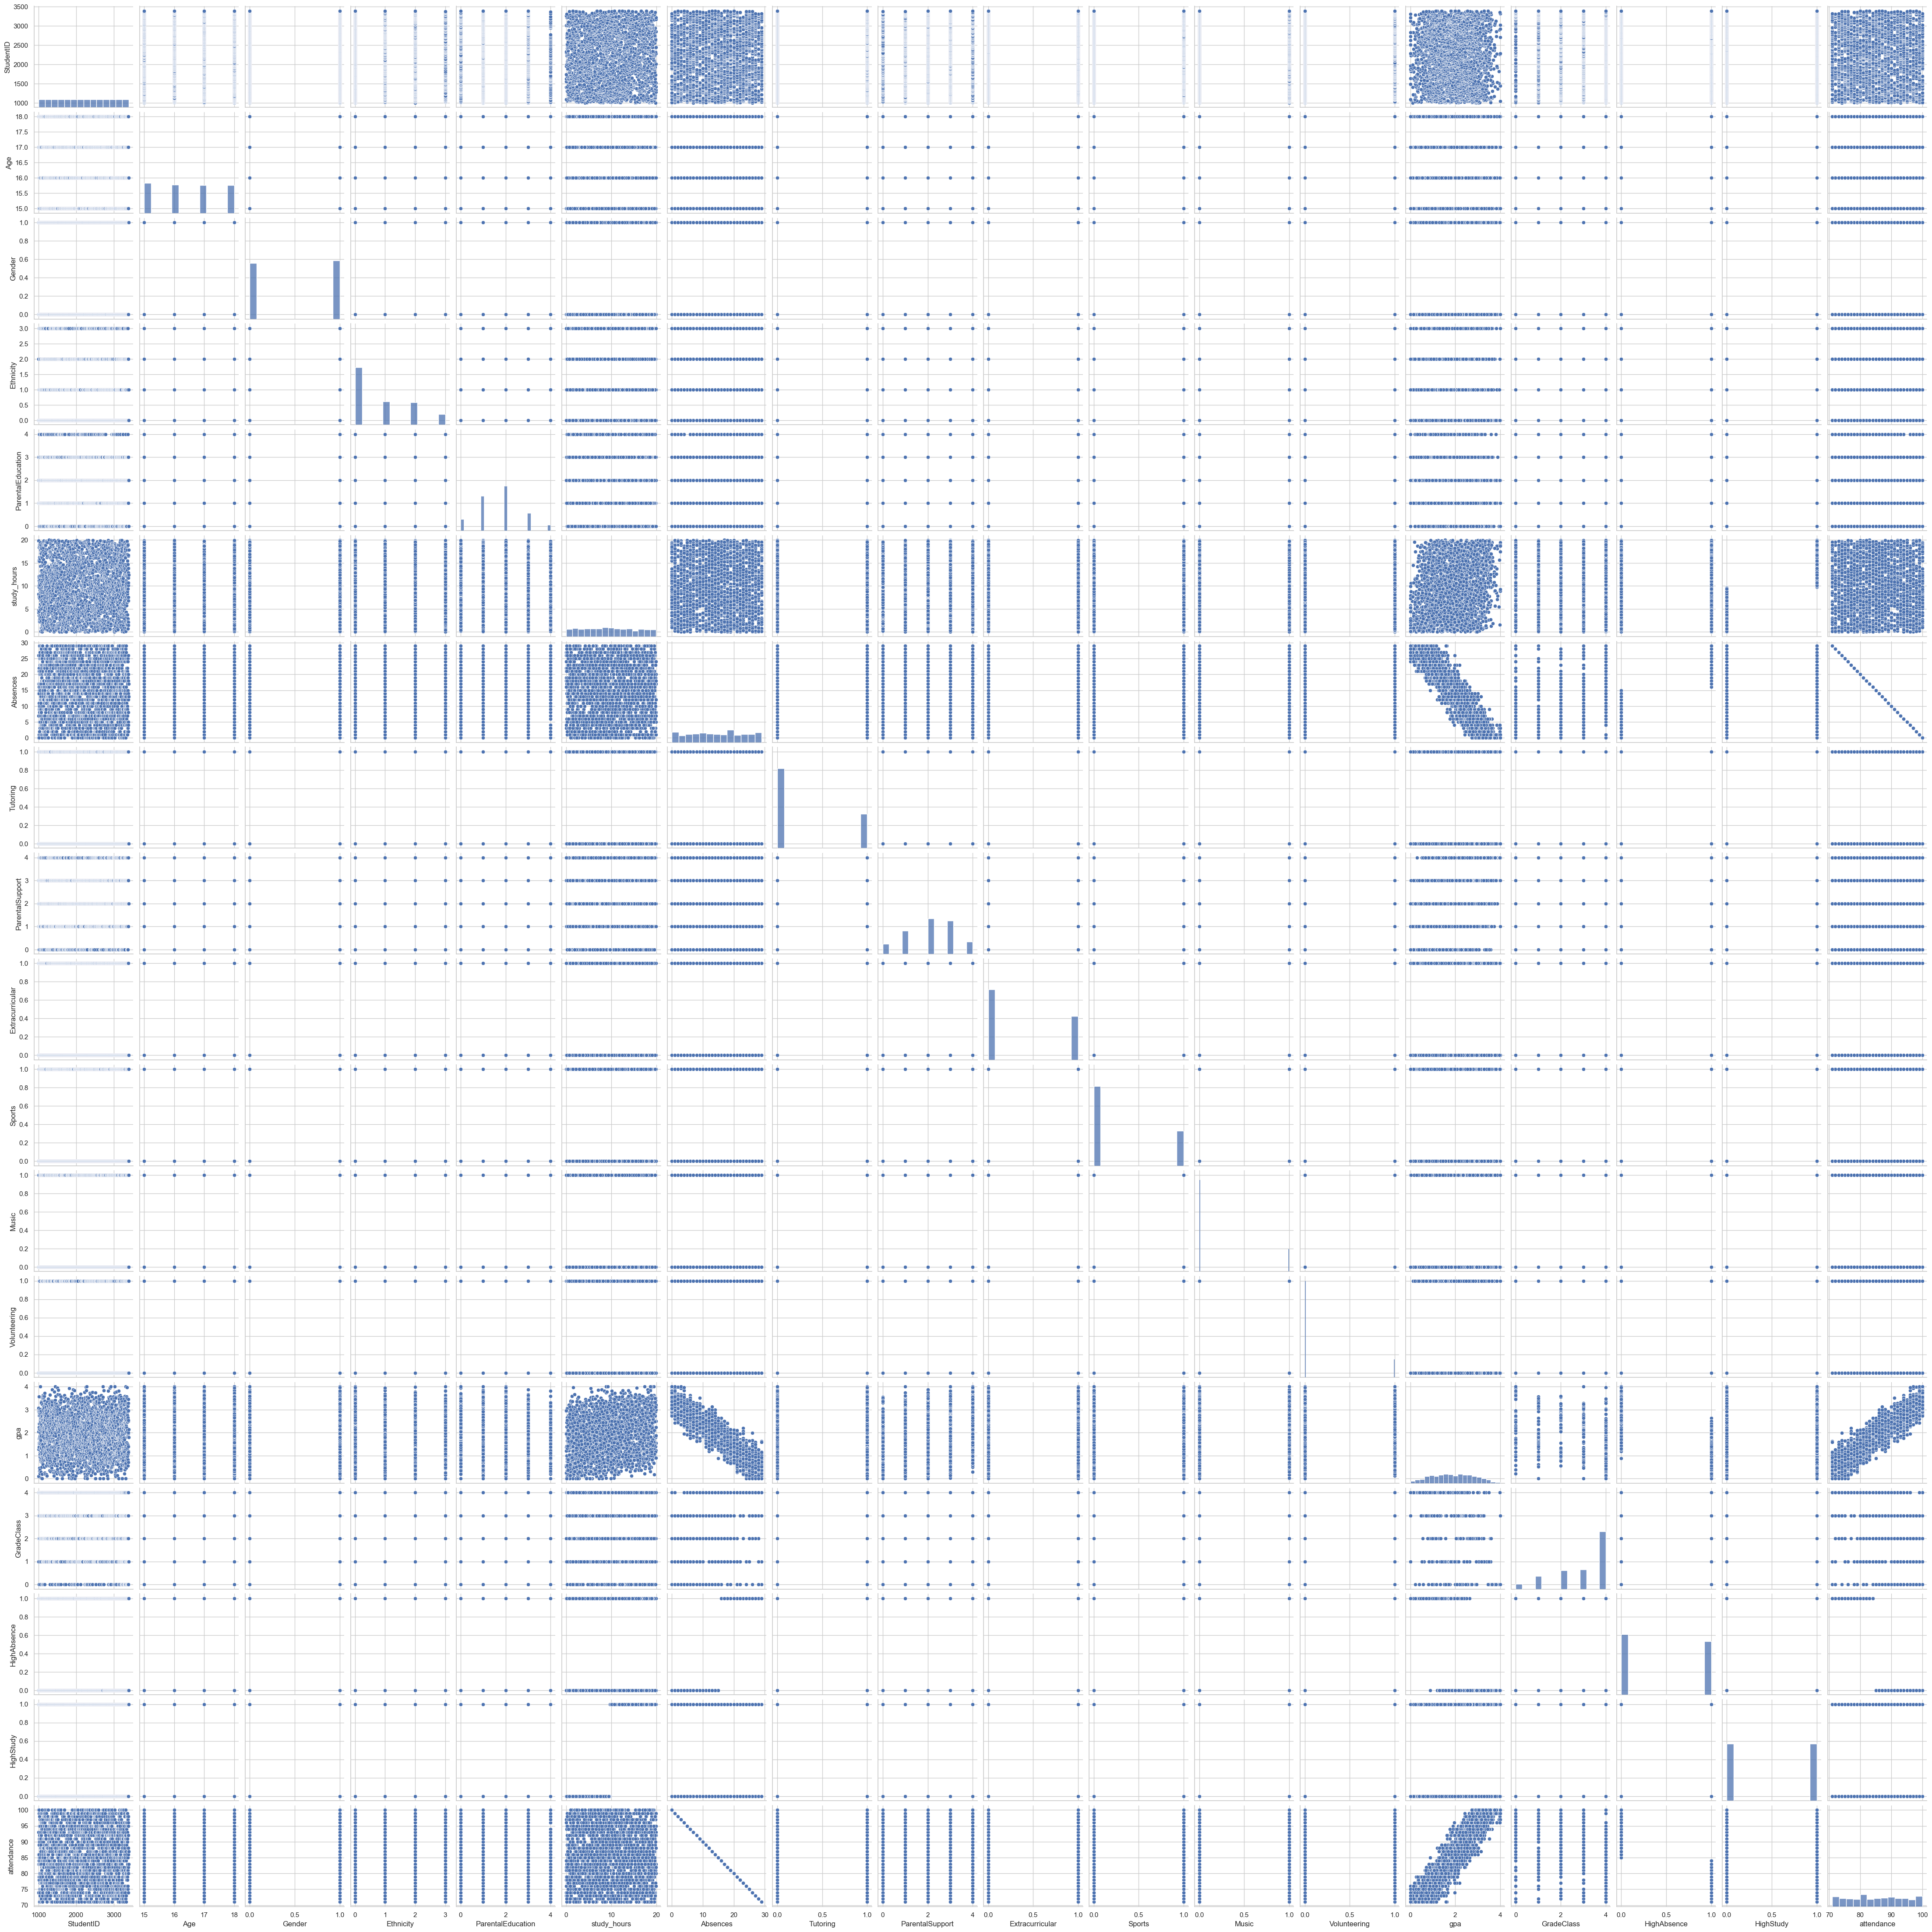

In [42]:
sns.pairplot(df)
plt.show()

### Grade Class Distribution

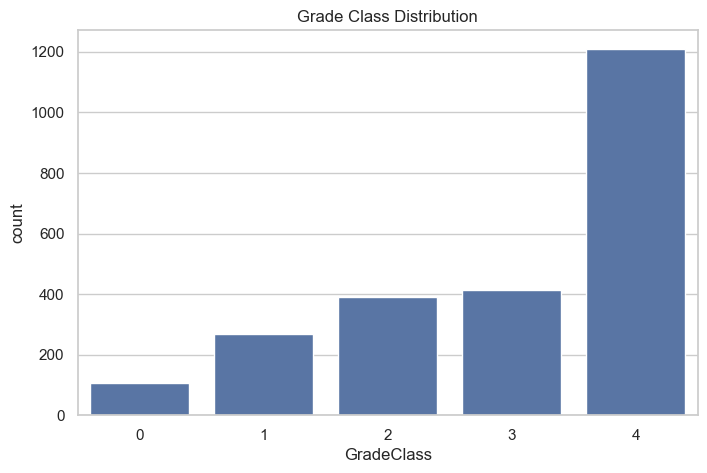

In [66]:
sns.countplot(x='GradeClass', data=df)
plt.title("Grade Class Distribution")
plt.show()

      StudentID       gpa  study_hours  Absences
1705       2706  4.000000     8.858282         0
2319       3320  4.000000     9.285447         0
1278       2279  4.000000    18.899696         3
44         1045  4.000000    18.921512         1
2028       3029  4.000000    18.656924         0
442        1443  4.000000    19.424398         0
1919       2920  4.000000    17.442121         1
1260       2261  3.984674     9.001905         2
2354       3355  3.979421     1.565490         4
1900       2901  3.951460    15.683744         1


### Boxplot

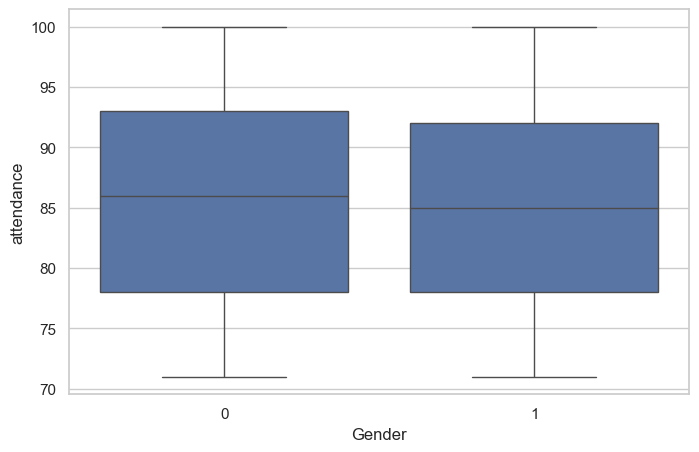

In [58]:
plt.figure()
sns.boxplot(x='Gender', y='attendance', data=df)
plt.show()

## 🧠 7. Key Insights

In [61]:
print('Average Attendance:', df['attendance'].mean())
print('Max Attendance:', df['attendance'].max())

Average Attendance: 85.45861204013377
Max Attendance: 100


### Top Performers

In [73]:
top_students = df.sort_values(by='gpa', ascending=False).head(10)
print(top_students[['StudentID','gpa','study_hours','Absences']])

      StudentID       gpa  study_hours  Absences
1705       2706  4.000000     8.858282         0
2319       3320  4.000000     9.285447         0
1278       2279  4.000000    18.899696         3
44         1045  4.000000    18.921512         1
2028       3029  4.000000    18.656924         0
442        1443  4.000000    19.424398         0
1919       2920  4.000000    17.442121         1
1260       2261  3.984674     9.001905         2
2354       3355  3.979421     1.565490         4
1900       2901  3.951460    15.683744         1


### Lowest Performers

In [75]:
low_students = df.sort_values(by='gpa', ascending=True).head(10)
print(low_students[['StudentID','gpa','study_hours','Absences']])

      StudentID  gpa  study_hours  Absences
963        1964  0.0     5.757590        26
1724       2725  0.0     7.301673        27
1622       2623  0.0     2.530906        29
2204       3205  0.0     0.237427        27
474        1475  0.0     1.444587        24
2124       3125  0.0     5.302465        27
1832       2833  0.0     9.962593        28
2219       3220  0.0     0.162164        29
1500       2501  0.0     2.873753        29
1286       2287  0.0     5.407665        26


### GPA by Parental Support

In [76]:
df.groupby('ParentalSupport')['gpa'].mean().sort_values(ascending=False)

ParentalSupport
4    2.191545
3    2.042409
2    1.884246
1    1.755700
0    1.540128
Name: gpa, dtype: float64

### GPA by Tutoring

In [77]:
df.groupby('Tutoring')['gpa'].mean().sort_values(ascending=False)

Tutoring
1    2.108325
0    1.818968
Name: gpa, dtype: float64

### GPA by Extracurricular

In [78]:
df.groupby('Extracurricular')['gpa'].mean().sort_values(ascending=False)

Extracurricular
1    2.015357
0    1.838316
Name: gpa, dtype: float64

### GPA by Gender + Tutoring

In [79]:
df.groupby(['Gender','Tutoring'])['gpa'].mean().sort_values(ascending=False)

Gender  Tutoring
0       1           2.119500
1       1           2.096544
0       0           1.825799
1       0           1.812694
Name: gpa, dtype: float64

### Students per Grade Class

In [80]:
df['GradeClass'].value_counts().sort_values(ascending=False)

GradeClass
4    1211
3     414
2     391
1     269
0     107
Name: count, dtype: int64

### Study Time Binning

In [81]:
df['StudyCategory'] = pd.cut(df['study_hours'],
                            bins=[0,5,10,15,20],
                            labels=['Low','Medium','High','Very High'])

df.groupby('StudyCategory')['gpa'].mean().sort_values(ascending=False)

C:\Users\ISV\AppData\Local\Temp\ipykernel_13040\2974763658.py:5: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('StudyCategory')['gpa'].mean().sort_values(ascending=False)


StudyCategory
Very High    2.105937
High         1.999016
Medium       1.849145
Low          1.691647
Name: gpa, dtype: float64